# 🧪 LABORATÓRIO — DETECÇÃO DE ANOMALIAS #


**OBJETIVO**

Detectar transações anômalas (fraudes) usando técnicas não supervisionadas.

## 1. Business Understanding ##

O objetivo deste experimento é identificar transações financeiras anômalas que possam indicar fraude.

A detecção precoce dessas transações permite reduzir perdas financeiras e melhorar a segurança dos sistemas.

Neste cenário, utilizamos técnicas não supervisionadas, pois fraudes são raras e nem sempre rotuladas.

## 2. Data Understanding ##

**Dataset real:** Credit Card Fraud - (PCA transformado)






In [ ]:
# download do dataset
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print("Forma do dataframe (linhas x colunas):")
print(df.shape)

Forma do dataframe (linhas x colunas):
(284807, 31)


### Dicionário simplificado ###

- Time → tempo da transação
- Amount → valor
- V1...V28 → variáveis transformadas (PCA)
- Class → 0 (normal), 1 (fraude)

### Explorando desbalanceamento ###


In [ ]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


## 3. Data Preparation ##


In [ ]:
from sklearn.preprocessing import StandardScaler

# separar features
X = df.drop("Class", axis=1)
y = df["Class"]

# normalizar Amount
scaler = StandardScaler()
X["Amount"] = scaler.fit_transform(X[["Amount"]])

## 4. Modelagem (Modeling) ##

### 4.1 Isolation Forest ###




In [ ]:
from sklearn.ensemble import IsolationForest

modelo_if = IsolationForest(
    contamination=0.002,  # % esperada de fraude
    random_state=42
)

modelo_if.fit(X)

pred_if = modelo_if.predict(X)

# converter para 0/1
pred_if = [1 if x == -1 else 0 for x in pred_if]

### 4.2 Local Outlier Factor ###

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.002
)

pred_lof = lof.fit_predict(X)
pred_lof = [1 if x == -1 else 0 for x in pred_lof]

  ## 5. Avaliação (Evaluation)

  

In [ ]:
from sklearn.metrics import classification_report

print("===== Isolation Forest =====")
print(classification_report(y, pred_if))

print("\n===== LOF =====")
print(classification_report(y, pred_lof))

===== Isolation Forest =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807


===== LOF =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.12      0.13      0.12       492

    accuracy                           1.00    284807
   macro avg       0.56      0.57      0.56    284807
weighted avg       1.00      1.00      1.00    284807



### **Interpretação** ###

- **Precision (fraude):** Quantas previsões de fraude estavam corretas

- **Recall (fraude):** Quantas fraudes reais foram detectadas

Contexto do resultado
Classe 0: 284.315 (normal)
Classe 1: 492 (anomalia)

👉 Isso dá ~0,17% de anomalias


🚨 **Primeira observação crítica**
- accuracy = 1.00
- weighted avg = 1.00

⚠️ **Isso é enganoso. Ignore.**

>Por quê?
> Porque o modelo pode acertar tudo como “normal” e ainda ter ~99.8% de accuracy.

🥇 **Isolation Forest**
- Classe 1 (anomalia)
- Precision = 0.24
- Recall = 0.28
- F1 = 0.26

**Interpretação**
- Ele detecta 28% das anomalias reais
-  Quando ele acusa anomalia, acerta 24%

Tradução prática:
- Pegou alguns casos relevantes
- Ainda perde a maioria
- Mas já tem sinal útil

🥈**LOF**
- Classe 1
- Precision = 0.12
- Recall = 0.13
- F1 = 0.12

**Interpretação**
- Detecta só 13% das anomalias
- Metade do desempenho do Isolation Forest

## 6. Visualização (reduzida)

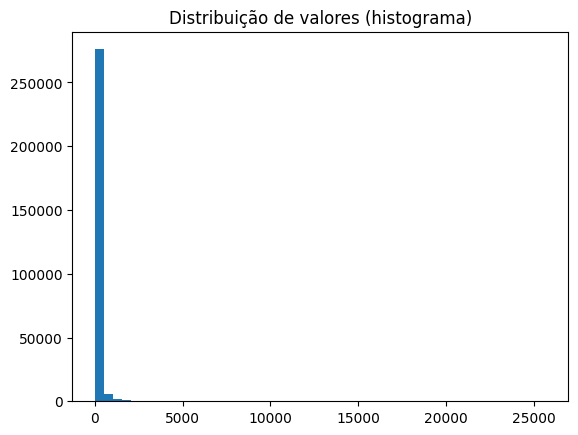

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["Amount"], bins=50)
plt.title("Distribuição de valores (histograma)")
plt.show()

**O que esse gráfico mostra?**

- distribuição extremamente assimétrica (skewed)
- grande concentração próxima de 0
- poucos valores muito altos (até ~25.000)

isso é uma cauda longa à direita (heavy tail)

**Problema central**
> dados extremamente desbalanceados + distribuição distorcida

**Isso impacta diretamente:**

- Isolation Forest
- LOF
qualquer modelo baseado em distância

O que está acontecendo na prática?
1. A maioria dos dados é “igual”
- valores próximos de 0
- pouca variação

👉 modelo tem dificuldade de distinguir padrões

 2. Poucos valores são MUITO diferentes
- outliers extremos
- muito distantes da média

👉 esses dominam a detecção


**Scores do Isolation Forest:**

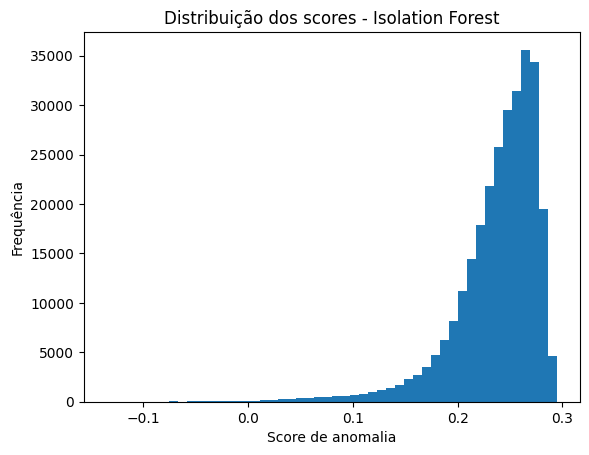

In [ ]:
scores_if = modelo_if.decision_function(X)

import matplotlib.pyplot as plt

plt.hist(scores_if, bins=50)
plt.title("Distribuição dos scores - Isolation Forest")
plt.xlabel("Score de anomalia")
plt.ylabel("Frequência")
plt.show()

**Interpretação:**

1. Forma da distribuição

-  Assimétrica à esquerda (left-skewed)
- Grande concentração entre ~0.22 e 0.29
- Cauda longa indo para valores menores (até negativos)

2. Interpretação no contexto do Isolation Forest


Lembre:
- scores maiores → mais normal
- scores menores → mais anômalo

**O que o gráfico mostra?**

🔹 Massa principal (direita) 👉 maioria dos dados é normal
- comportamento esperado
- boa densidade de pontos “não anômalos”

🔹 Cauda à esquerda 👉 poucos pontos com score baixo
- possíveis anomalias reais
- quanto mais à esquerda → mais suspeito

3. Insight importante

> O modelo identificou um pequeno conjunto de pontos potencialmente anômalos

👉 Isso é bom sinal:

- não está classificando tudo como anomalia
- nem ignorando possíveis outliers

4. Ponto crítico (atenção) 👉 A separação não é extremamente nítida

- não há “gap” claro entre normal e anômalo
- a cauda é contínua

Isso indica: As anomalias não são extremamente evidentes (caso difícil)

**Extraindo os dados anômalos**



In [ ]:

df["Anomaly_IF"] = pred_if

anomalias = df[df["Anomaly_IF"] == -1]

anomalias

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Anomaly_IF


In [ ]:
# ==========================================================
# REDUÇÃO DE DIMENSIONALIDADE (PCA)
# ==========================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# criar dataframe para plot
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": y,
    "Anomaly_IF": pred_if
})

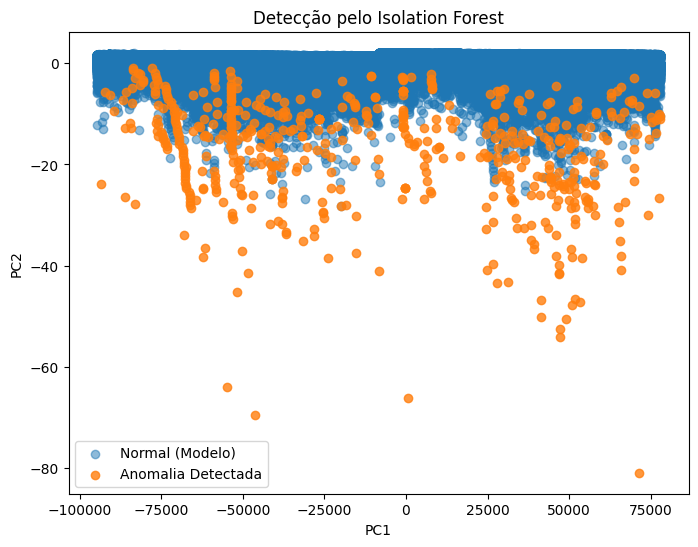

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    plot_df[plot_df["Anomaly_IF"] == 0]["PC1"],
    plot_df[plot_df["Anomaly_IF"] == 0]["PC2"],
    alpha=0.5,
    label="Normal (Modelo)",
)

plt.scatter(
    plot_df[plot_df["Anomaly_IF"] == 1]["PC1"],
    plot_df[plot_df["Anomaly_IF"] == 1]["PC2"],
    alpha=0.8,
    label="Anomalia Detectada",
)

plt.legend()
plt.title("Detecção pelo Isolation Forest")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

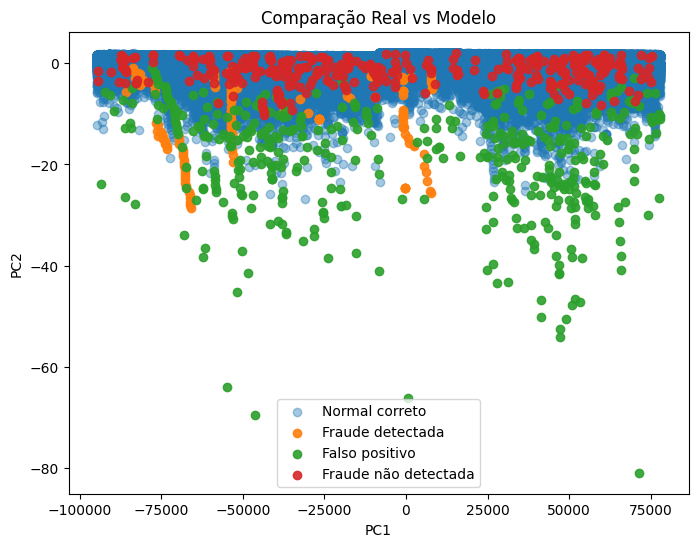

In [ ]:
plt.figure(figsize=(8,6))

# normais corretos
plt.scatter(
    plot_df[(plot_df["Class"] == 0) & (plot_df["Anomaly_IF"] == 0)]["PC1"],
    plot_df[(plot_df["Class"] == 0) & (plot_df["Anomaly_IF"] == 0)]["PC2"],
    alpha=0.4,
    label="Normal correto"
)

# fraudes detectadas
plt.scatter(
    plot_df[(plot_df["Class"] == 1) & (plot_df["Anomaly_IF"] == 1)]["PC1"],
    plot_df[(plot_df["Class"] == 1) & (plot_df["Anomaly_IF"] == 1)]["PC2"],
    alpha=0.9,
    label="Fraude detectada"
)

# erro (falso positivo)
plt.scatter(
    plot_df[(plot_df["Class"] == 0) & (plot_df["Anomaly_IF"] == 1)]["PC1"],
    plot_df[(plot_df["Class"] == 0) & (plot_df["Anomaly_IF"] == 1)]["PC2"],
    alpha=0.9,
    label="Falso positivo"
)

# erro (fraude não detectada)
plt.scatter(
    plot_df[(plot_df["Class"] == 1) & (plot_df["Anomaly_IF"] == 0)]["PC1"],
    plot_df[(plot_df["Class"] == 1) & (plot_df["Anomaly_IF"] == 0)]["PC2"],
    alpha=0.9,
    label="Fraude não detectada"
)

plt.legend()
plt.title("Comparação Real vs Modelo")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()-

## 7. Deployment (Discussão) ##

Aplicações práticas:

- bloqueio automático de transações
- geração de alertas
- priorização de análise manual

Desafios:
- falsos positivos
- custo operacional
- adaptação contínua

## Conclusão

A detecção de anomalias permite identificar padrões raros em grandes volumes de dados.

Neste experimento, técnicas como Isolation Forest e LOF mostraram capacidade de identificar transações suspeitas, mesmo em um cenário altamente desbalanceado.

A aplicação prática exige equilíbrio entre precisão e recall, além de validação com especialistas.